# Graph Coloring Constraint Satisfaction Dataset — Demo

This notebook demonstrates the **Graph Coloring Constraint Satisfaction Dataset** with parameterized difficulty.

**What this artifact does:**
- Generates graph coloring constraint satisfaction problems using Erdos-Renyi random graphs
- Each problem has a natural language description, a verified ground-truth coloring, and difficulty metadata
- Difficulty scales from trivial (4 nodes, 4 colors, sparse) to extreme (12 nodes, 3 colors, moderate density)
- Every instance is verified solvable by an exact backtracking solver with connected-graph and uniqueness filters

**In this demo** we load a curated subset of the dataset, explore the data structure, regenerate a few problems from scratch, verify colorings, and visualize the difficulty progression.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages are pre-installed on Colab; install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'networkx==3.4.2')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
from typing import Optional

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

## Load Dataset

Load the curated mini demo dataset (10 examples spanning difficulty levels 1-20) from GitHub, with local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/dataset_iter1_graph_coloring/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples from dataset '{data['datasets'][0]['dataset']}'")
print(f"Metadata: {json.dumps(data['metadata'], indent=2)}")

Loaded 10 examples from dataset 'graph_coloring_full'
Metadata: {
  "source": "synthetic_generation",
  "description": "Graph Coloring Constraint Satisfaction Dataset with Parameterized Difficulty",
  "generation_method": "Erdos-Renyi random graphs with exact backtracking k-coloring solver",
  "total_problems": 10,
  "difficulty_levels": 20,
  "problems_per_level": 20,
  "node_range": "4-12",
  "color_range": "3-4",
  "note": "Curated mini subset for demo (10 examples across difficulty levels)"
}


## Configuration

Tunable parameters for the demo. We generate a small number of problems per level for speed.

In [5]:
# --- Config ---
# Number of difficulty levels to generate (original: 20)
NUM_LEVELS = 20
# Problems to generate per difficulty level (original: 20)
PROBLEMS_PER_LEVEL = 20
# Max random attempts per problem before giving up (original: 200)
MAX_ATTEMPTS_PER_PROBLEM = 200

# Difficulty table: (level, num_nodes, edge_probability, num_colors)
DIFFICULTY_TABLE = [
    (1,  4,  0.30, 4),
    (2,  4,  0.50, 4),
    (3,  4,  0.60, 3),
    (4,  5,  0.30, 4),
    (5,  5,  0.40, 3),
    (6,  5,  0.60, 3),
    (7,  6,  0.30, 3),
    (8,  6,  0.50, 3),
    (9,  7,  0.30, 3),
    (10, 7,  0.40, 3),
    (11, 7,  0.55, 3),
    (12, 8,  0.30, 3),
    (13, 8,  0.40, 3),
    (14, 8,  0.50, 3),
    (15, 9,  0.35, 3),
    (16, 9,  0.45, 3),
    (17, 10, 0.30, 3),
    (18, 10, 0.40, 3),
    (19, 11, 0.35, 3),
    (20, 12, 0.35, 3),
][:NUM_LEVELS]

# Color name mappings
COLOR_NAMES_3 = ["Red", "Green", "Blue"]
COLOR_NAMES_4 = ["Red", "Green", "Blue", "Yellow"]

## Explore Loaded Data

Inspect the structure of examples from the pre-generated dataset.

In [6]:
# Show structure of first example
ex = examples[0]
print("Example keys:", list(ex.keys()))
print(f"\nDifficulty level: {ex['metadata_difficulty_level']}")
print(f"Nodes: {ex['metadata_num_nodes']}, Edges: {ex['metadata_num_edges']}, Colors: {ex['metadata_num_colors']}")
print(f"Edge density: {ex['metadata_edge_density']}")
print(f"Adjacency: {ex['metadata_graph_adjacency']}")
print(f"\n--- Input (problem statement) ---\n{ex['input'][:300]}")
print(f"\n--- Output (ground truth) ---\n{ex['output']}")

Example keys: ['input', 'output', 'metadata_difficulty_level', 'metadata_num_nodes', 'metadata_num_edges', 'metadata_num_colors', 'metadata_edge_density', 'metadata_graph_adjacency', 'metadata_fold', 'metadata_row_index', 'metadata_task_type']

Difficulty level: 1
Nodes: 4, Edges: 3, Colors: 4
Edge density: 0.3
Adjacency: [[0, 2], [0, 3], [1, 3]]

--- Input (problem statement) ---
Given a graph with 4 nodes (labeled Node 0 through Node 3) and the following edges:
(Node 0, Node 2), (Node 0, Node 3), (Node 1, Node 3)

Color each node using exactly one of these colors: Red, Green, Blue, Yellow.
The constraint is that no two nodes connected by an edge may share the same color.

P

--- Output (ground truth) ---
Node 0: Red, Node 1: Red, Node 2: Green, Node 3: Green


## Backtracking k-Coloring Solver

Exact solver that finds a valid k-coloring via backtracking, plus verification function.

In [7]:
def find_k_coloring(graph: nx.Graph, k: int) -> Optional[dict[int, int]]:
    """Backtracking solver: returns a valid k-coloring dict {node: color} or None."""
    nodes = sorted(graph.nodes())
    adj = {n: set(graph.neighbors(n)) for n in nodes}
    coloring: dict[int, int] = {}

    def backtrack(idx: int) -> bool:
        if idx == len(nodes):
            return True
        node = nodes[idx]
        for color in range(k):
            if all(coloring.get(neighbor) != color for neighbor in adj[node]):
                coloring[node] = color
                if backtrack(idx + 1):
                    return True
                del coloring[node]
        return False

    if backtrack(0):
        return dict(coloring)
    return None


def verify_coloring(graph: nx.Graph, coloring: dict[int, int], k: int) -> bool:
    """Check: all nodes colored, all colors in range, no adjacent same-color."""
    if set(coloring.keys()) != set(graph.nodes()):
        return False
    if any(c < 0 or c >= k for c in coloring.values()):
        return False
    for u, v in graph.edges():
        if coloring[u] == coloring[v]:
            return False
    return True

## Verify Loaded Dataset Examples

Re-verify that every coloring in the loaded dataset is valid by reconstructing each graph and checking constraints.

In [8]:
verified = 0
for i, ex in enumerate(examples):
    G = nx.Graph()
    G.add_nodes_from(range(ex["metadata_num_nodes"]))
    G.add_edges_from([tuple(e) for e in ex["metadata_graph_adjacency"]])

    # Parse output coloring
    color_map = COLOR_NAMES_4 if ex["metadata_num_colors"] == 4 else COLOR_NAMES_3
    coloring = {}
    for part in ex["output"].split(", "):
        node_str, color_str = part.split(": ")
        node_id = int(node_str.replace("Node ", ""))
        color_id = color_map.index(color_str)
        coloring[node_id] = color_id

    ok = verify_coloring(G, coloring, ex["metadata_num_colors"])
    status = "PASS" if ok else "FAIL"
    if ok:
        verified += 1
    print(f"  Example {i} (level {ex['metadata_difficulty_level']:2d}, {ex['metadata_num_nodes']} nodes, {ex['metadata_num_edges']} edges): [{status}]")

print(f"\nVerified {verified}/{len(examples)} colorings valid")

  Example 0 (level  1, 4 nodes, 3 edges): [PASS]
  Example 1 (level  3, 4 nodes, 5 edges): [PASS]
  Example 2 (level  5, 5 nodes, 5 edges): [PASS]
  Example 3 (level  7, 6 nodes, 6 edges): [PASS]
  Example 4 (level 10, 7 nodes, 8 edges): [PASS]
  Example 5 (level 13, 8 nodes, 11 edges): [PASS]
  Example 6 (level 15, 9 nodes, 13 edges): [PASS]
  Example 7 (level 17, 10 nodes, 12 edges): [PASS]
  Example 8 (level 19, 11 nodes, 20 edges): [PASS]
  Example 9 (level 20, 12 nodes, 21 edges): [PASS]

Verified 10/10 colorings valid


## Generate New Problems

Generate fresh graph coloring problems using Erdos-Renyi random graphs, the same method used to create the full dataset.

In [9]:
def format_problem_text(n: int, edges: list[tuple[int, int]], k: int) -> str:
    """Create natural language problem statement."""
    edge_strs = [f"(Node {u}, Node {v})" for u, v in edges]
    edge_list = ", ".join(edge_strs)
    color_names = COLOR_NAMES_4[:k] if k == 4 else COLOR_NAMES_3[:k]
    color_str = ", ".join(color_names)
    return (
        f"Given a graph with {n} nodes (labeled Node 0 through Node {n - 1}) "
        f"and the following edges:\n{edge_list}\n\n"
        f"Color each node using exactly one of these colors: {color_str}.\n"
        f"The constraint is that no two nodes connected by an edge may share the same color.\n\n"
        f"Provide a valid coloring by listing each node and its assigned color."
    )


def format_coloring_output(coloring: dict[int, int], k: int) -> str:
    """Format coloring as ground truth output string."""
    color_names = COLOR_NAMES_4[:k] if k == 4 else COLOR_NAMES_3[:k]
    parts = [f"Node {node}: {color_names[color]}" for node, color in sorted(coloring.items())]
    return ", ".join(parts)


def generate_level(level: int, n: int, p: float, k: int) -> list[dict]:
    """Generate PROBLEMS_PER_LEVEL valid graph coloring problems for a given level."""
    problems = []
    seen_edge_sets = set()
    attempt = 0
    current_p = p

    while len(problems) < PROBLEMS_PER_LEVEL:
        attempt += 1
        if attempt > MAX_ATTEMPTS_PER_PROBLEM * PROBLEMS_PER_LEVEL:
            current_p = max(current_p - 0.05, 0.10)
            attempt = 0
            seen_edge_sets.clear()
            problems.clear()
            continue

        seed = level * 10000 + attempt
        G = nx.erdos_renyi_graph(n, current_p, seed=seed)

        if not nx.is_connected(G) or G.number_of_edges() < 2:
            continue

        coloring = find_k_coloring(G, k)
        if coloring is None:
            continue

        edge_set = frozenset(frozenset(e) for e in G.edges())
        if edge_set in seen_edge_sets:
            continue
        seen_edge_sets.add(edge_set)

        assert verify_coloring(G, coloring, k)

        edges_sorted = sorted([sorted(e) for e in G.edges()])
        record = {
            "input": format_problem_text(n, [(u, v) for u, v in edges_sorted], k),
            "output": format_coloring_output(coloring, k),
            "difficulty_level": level,
            "num_nodes": n,
            "num_edges": G.number_of_edges(),
            "num_colors": k,
            "edge_density": round(current_p, 2),
            "graph_adjacency": edges_sorted,
            "metadata_fold": f"level_{level:02d}",
        }
        problems.append(record)

    return problems


# Generate problems across configured levels
import time
start = time.time()
all_records = []
for level, n, p, k in DIFFICULTY_TABLE:
    records = generate_level(level, n, p, k)
    all_records.extend(records)
    print(f"  Level {level:2d} (N={n}, p={p:.2f}, K={k}): {len(records)} problems")

elapsed = time.time() - start
print(f"\nGenerated {len(all_records)} total problems in {elapsed:.2f}s")

  Level  1 (N=4, p=0.30, K=4): 20 problems
  Level  2 (N=4, p=0.50, K=4): 20 problems
  Level  3 (N=4, p=0.60, K=3): 20 problems
  Level  4 (N=5, p=0.30, K=4): 20 problems
  Level  5 (N=5, p=0.40, K=3): 20 problems
  Level  6 (N=5, p=0.60, K=3): 20 problems
  Level  7 (N=6, p=0.30, K=3): 20 problems
  Level  8 (N=6, p=0.50, K=3): 20 problems
  Level  9 (N=7, p=0.30, K=3): 20 problems
  Level 10 (N=7, p=0.40, K=3): 20 problems
  Level 11 (N=7, p=0.55, K=3): 20 problems
  Level 12 (N=8, p=0.30, K=3): 20 problems
  Level 13 (N=8, p=0.40, K=3): 20 problems
  Level 14 (N=8, p=0.50, K=3): 20 problems
  Level 15 (N=9, p=0.35, K=3): 20 problems
  Level 16 (N=9, p=0.45, K=3): 20 problems
  Level 17 (N=10, p=0.30, K=3): 20 problems
  Level 18 (N=10, p=0.40, K=3): 20 problems
  Level 19 (N=11, p=0.35, K=3): 20 problems
  Level 20 (N=12, p=0.35, K=3): 20 problems

Generated 400 total problems in 0.14s


## Visualization

1. **Summary table** of the loaded dataset examples across difficulty levels
2. **Graph visualization** of a sample coloring problem
3. **Difficulty progression** showing how node/edge counts scale with difficulty

Level Nodes Edges Colors  Density       Fold
--------------------------------------------------------------------------------
    1     4     3      4     0.30   level_01
    3     4     5      3     0.60   level_03
    5     5     5      3     0.40   level_05
    7     6     6      3     0.30   level_07
   10     7     8      3     0.40   level_10
   13     8    11      3     0.40   level_13
   15     9    13      3     0.35   level_15
   17    10    12      3     0.30   level_17
   19    11    20      3     0.35   level_19
   20    12    21      3     0.35   level_20


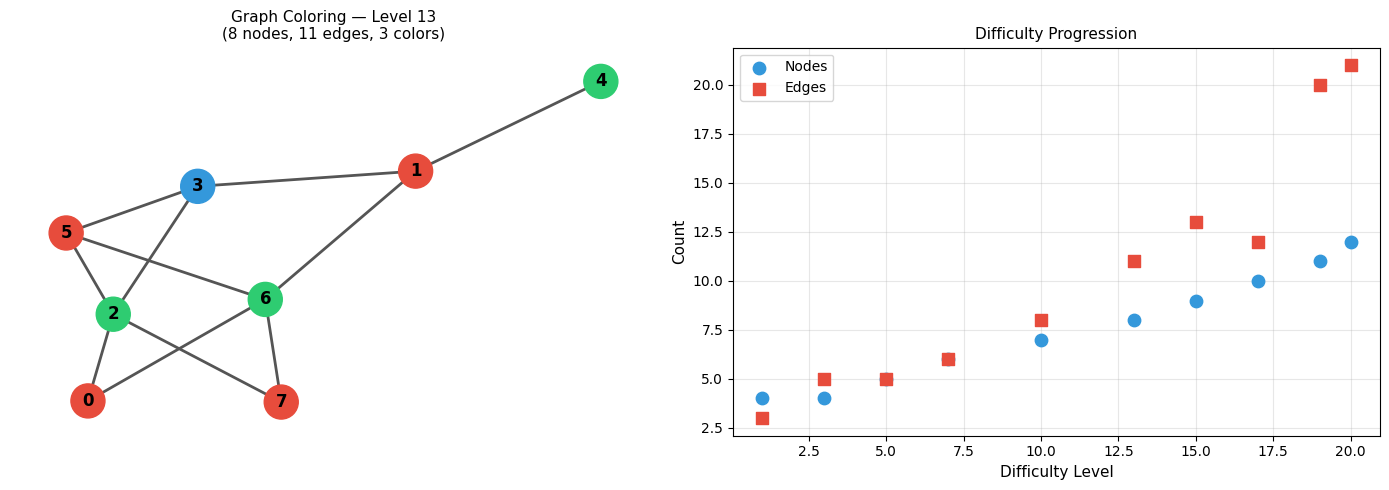

Saved graph_coloring_demo.png


In [10]:
# --- Summary table of loaded examples ---
print("=" * 80)
print(f"{'Level':>5} {'Nodes':>5} {'Edges':>5} {'Colors':>6} {'Density':>8} {'Fold':>10}")
print("-" * 80)
for ex in examples:
    print(f"{ex['metadata_difficulty_level']:>5} {ex['metadata_num_nodes']:>5} "
          f"{ex['metadata_num_edges']:>5} {ex['metadata_num_colors']:>6} "
          f"{ex['metadata_edge_density']:>8.2f} {ex['metadata_fold']:>10}")
print("=" * 80)

# --- Visualize a sample graph coloring ---
# Pick a medium-difficulty example for visual interest
mid_idx = len(examples) // 2
sample = examples[mid_idx]

G = nx.Graph()
G.add_nodes_from(range(sample["metadata_num_nodes"]))
G.add_edges_from([tuple(e) for e in sample["metadata_graph_adjacency"]])

# Parse coloring from output
cmap = COLOR_NAMES_4 if sample["metadata_num_colors"] == 4 else COLOR_NAMES_3
parsed_coloring = {}
for part in sample["output"].split(", "):
    ns, cs = part.split(": ")
    parsed_coloring[int(ns.replace("Node ", ""))] = cs

# Map color names to matplotlib colors
color_mapping = {"Red": "#e74c3c", "Green": "#2ecc71", "Blue": "#3498db", "Yellow": "#f1c40f"}
node_colors = [color_mapping[parsed_coloring[n]] for n in sorted(G.nodes())]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: graph coloring
ax = axes[0]
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, ax=ax, with_labels=True, node_color=node_colors,
        node_size=600, font_size=12, font_weight='bold',
        edge_color='#555555', width=2)
ax.set_title(f"Graph Coloring — Level {sample['metadata_difficulty_level']}\n"
             f"({sample['metadata_num_nodes']} nodes, {sample['metadata_num_edges']} edges, "
             f"{sample['metadata_num_colors']} colors)", fontsize=11)

# Right: difficulty progression from loaded data
ax2 = axes[1]
levels = [ex["metadata_difficulty_level"] for ex in examples]
nodes = [ex["metadata_num_nodes"] for ex in examples]
edges = [ex["metadata_num_edges"] for ex in examples]

ax2.scatter(levels, nodes, c="#3498db", s=80, label="Nodes", zorder=3)
ax2.scatter(levels, edges, c="#e74c3c", s=80, marker="s", label="Edges", zorder=3)
ax2.set_xlabel("Difficulty Level", fontsize=11)
ax2.set_ylabel("Count", fontsize=11)
ax2.set_title("Difficulty Progression", fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("graph_coloring_demo.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved graph_coloring_demo.png")